### Constructing simple plots

Construction of plots generally follows the article from the baseline study. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from actors import Survey
from plots import * # fontsizes

In [2]:
# from dataframe_gymnastics import (
#     map_institution,
#     year_2019,
#     year_2026,
#     load_2019_data_students,
#     load_2019_data_educators,
#     load_2019_data_admintech,
#     load_2026_data_students,
#     load_2026_data_educators, 
#     load_2026_data_admintech,
#     merge_2019_with_2026
# )

# df_2019_students, common_questions_students_2019 = load_2019_data_students()
# df_2019_educators, common_questions_educators_2019 = load_2019_data_educators()
# df_2019_admintech, common_questions_2019_admintech = load_2019_data_admintech()
# df_2026_students = load_2026_data_students()
# df_2026_educators = load_2026_data_educators()
# df_2026_admintech = load_2026_data_admintech()

# # define the special cases of mismatch between questions we can analyse, but have slightly different names
# # key: 2019 question, value: 2026 question
# # in merge: rewrite the 2019 question to match the 2026 question, so that we can merge the dataframes

# # question "key" should be renamed to "value" in 2019, to match 2026
# special_cases_good_questions = {''
#     "educators": {
#         "Students.3": "students.2",     # <- mismatch in numbering
#         # "Informal feedback from students": "Informal feed-back from students"
#         "Collaborative skills.3": "Collaborative skills",
#     },
#     "students": {},
#     "admintech": {}
# }
# (
#     df_students, 
#     df_educators, 
#     df_admintech, 
#     common_questions_students, 
#     common_questions_educators, 
#     common_questions_admintech
# ) = merge_2019_with_2026(
#         df_2019_students, 
#         df_2019_educators, 
#         df_2019_admintech, 
#         df_2026_students, 
#         df_2026_educators, 
#         df_2026_admintech,
#         special_cases_good_questions
#     )

In [3]:

import matplotlib
from axes import detect_axis


def make_shared_histogram(questions_to_plot, survey, title, hide=True, concatenate_counts_with=None):
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Determine the number of groups and options
    num_questions = len(questions_to_plot)
    
    # Define bar widths and spacing
    total_width = 0.8  # Total space allocated for all bars at one X-position
    bar_width = total_width / num_questions
    
    # Color palette or list of colors to differentiate the questions
    # colors = plt.cm.get_cmap('tab10', num_questions) 
    # colors = plt.cm.get_cmap('autumn', num_questions) 
    colors = matplotlib.colormaps["tab20"]

    # Loop through each question and plot its bars with an offset
    for i, question_text in enumerate(questions_to_plot):
        question = survey.search(question_text)
        if isinstance(question, int):
            print(f"{question_text = } not found in survey")
            continue  # Skip if counts are empty or None

        counts = question.get_counts()  # Assuming this returns a list/array of values
        if concatenate_counts_with is not None:
            # Find the question to concatenate with
            concat_question = concatenate_counts_with.search(question_text)
            if isinstance(concat_question, int):
                print(f"Concatenation question '{concatenate_counts_with}' not found for '{question_text}'.")
                continue  # Skip if concatenation question is not found

            # Concatenate counts
            counts = question.get_counts() +  concat_question.get_counts()
        
        # Setup X positions for the response options (e.g., 1 to 7)
        if counts is None:
            print("No counts")
            print(f"{question_text = }")
            print(f"{question.axis = }")
            question.axis = detect_axis(question.responses)
            print(f"{question.axis = }")
            counts = question.get_counts()
            print(f"{question.counts = }")
            print(f"{question.responses = }")

        num_options = len(counts)
        x_indices = np.arange(1, num_options + 1)
        
        # Calculate the specific offset for this question's bars
        offset = (i - (num_questions - 1) / 2) * bar_width
        
        # Plot the individual bar chart
        ax.bar(
            x_indices + offset, 
            counts/np.sum(counts),  # Normalize counts to get proportions
            width=bar_width, 
            label=question_text, 
            color=colors(i),
            edgecolor='black' 
        )
    num_options = len(counts)
    # Formatting the shared layout
    # use the detected axis as ticks
    ticks_numbers = np.arange(1, num_options + 1)
    ax.set_xticks(ticks_numbers, labels=question.axis[1])
    # ax.set_xticks()
    # ax.set_xticklabels([f"{i}" for i in range(1, num_options + 1)])
    
    ax.set_xlabel('Scale', fontsize=ax_title_fs)
    ax.set_ylabel('Density', fontsize=ax_title_fs) # Clean, large text like your example
    
    ax.legend() 
    
    fig.suptitle(title, fontsize=fig_title_fs)#, fontweight='bold')
    fig.tight_layout()
    
    # Using a generic name since it's a shared plot now, not just one question
    fig.savefig(r"..\figures\shared_histograms" + f"\\{title.split()[0]}" + f"\\{sanitize_key(title.replace(' ', '_').replace('?', '').replace("\n", ''))}.png", bbox_inches='tight')
    if hide: plt.close()

#### 2019 Educators

In [4]:

import pandas as pd
df_uib_2019_educators_path = "..\\2019data\\uib_2019_educators.xlsx"
# df_uib_2019_educators_path = r"C:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\all data exel\uib.1.data-99922-2024-02-15-1522.xlsx"
# "C:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\all data exel\uib.3.data-99928-2024-02-15-1528.xlsx"
df_uibgeophys_2019_educators_path = "..\\2019data\\uibgeophys_2019_educators.xlsx"
df_uio_2019_educators_path = "..\\2019data\\uio_2019_educators.xlsx"
df_uit_2019_educators_path = "..\\2019data\\uit_2019_educators.xlsx"
df_unis_2019_educators_path = "..\\2019data\\unis_2019_educators.xlsx"
df_uib_2019_educators_raw = pd.read_excel(df_uib_2019_educators_path)
df_uibgeophys_2019_educators_raw = pd.read_excel(df_uibgeophys_2019_educators_path)
df_uio_2019_educators_raw = pd.read_excel(df_uio_2019_educators_path)
df_uit_2019_educators_raw = pd.read_excel(df_uit_2019_educators_path)
df_unis_2019_educators_raw = pd.read_excel(df_unis_2019_educators_path)



search_query = "Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution"

# print the column names of the dataframes
print("Column names of df_uib_2019_educators_raw:")
for col in sorted(df_uib_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uibgeophys_2019_educators_raw:")
for col in sorted(df_uibgeophys_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uio_2019_educators_raw:")
for col in sorted(df_uio_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uit_2019_educators_raw:")
for col in sorted(df_uit_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_unis_2019_educators_raw:")
for col in sorted(df_unis_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

Column names of df_uib_2019_educators_raw:
Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution

Column names of df_uibgeophys_2019_educators_raw:

Column names of df_uio_2019_educators_raw:

Column names of df_uit_2019_educators_raw:
Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution

Column names of df_unis_2019_educators_raw:
Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution


In [5]:
from dataframe_gymnastics import load_loose_educators_data_2019, map_institution


def plot_2019_educator_questions(survey, group):
    std_title = f"Educators 2019\n{group}\n"
    questions_to_plot = [
        "Spatial skills (romlig forståelse)",
        "Fieldwork skills",
        "Laboratory skills",
        "Modelling/computing skills",
        "Critical thinking",
        "Theoretical understanding",
        "Collaborative skills", # not the same in 2026
        "Working in interdisciplinary teams",
        "Scientific writing and reading competence (literacy)",
        "Quantitative competence (ability to interpret data /numeracy)",
        "Communicating scientific/technical content"
    ]
    title = std_title + "To what extent do you believe the following skills\nwill be important for geoscientist in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)

    questions_to_plot = [
        "To what extent does the education prepare students for future work in geoscience?",
    ]
    title= std_title + "To what extent does the education at your\ninstitution prepare students for their future work in geoscience?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)
    questions_to_plot = [
        "To what extent is there coherence (connectedness) between the courses in the study programme?"
    ]
    title = std_title + "To what extent do you think there is coherence (connectedness)\nbetween the courses in the study programme?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)


    questions_to_plot = [
        "Spatial skills (romlig forståelse).1",
        "Fieldwork skills.1",
        "Laboratory skills.1",
        "Modelling/computing skills.1",
        "Critical thinking.1",
        "Theoretical understanding.1",
        "Collaborative skills.1", # !!! refer to internship question in 2026, do not analyse
        "Working in interdisciplinary teams.1",
        "Scientific writing and reading competence (literacy).1",
        "Quantitative competence (ability to interpret data /numeracy).1",
        "Communicating scientific/technical content.1"
    ]
    title = std_title + "To what extent do the students acquire these skills\nthrough the geoscience study programme at your institution?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)


    questions_to_plot = [
        "The teachers’ have excellent academic competences",
        # "The teachers’ have excellent pedagogical competences", # <- not found in two of the surveys
        "The collegial collaboration in regard to research is excellent",
        "The collegial collaboration in regard to teaching is excellent",
        "The collegial collaboration between academic staff and technical/administration staff is excellent",
        "The general quality of the study programme is excellent"
    ]
    title = std_title + "To what extent do you agree or disagree with the\nfollowing statements about your department?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)


    questions_to_plot = [
        "The geoscience department at UiT",
        "The geoscience department at UNIS",
        "The geoscience department at UiO",
        "The geoscience department at UiB",
        "Other departments (not geoscience) at a university",
        "Other geoscience departments at Norwegian universities",
        "Other geoscience departments at non-Norwegian universities",
        "Research institutions"
    ]
    title = std_title + "To what extent do you collaborate with persons at the following\ninstitutions in regard to university teaching/development?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)

    questions_to_plot = [
        "Academic staff",
        "Students",
        "Administrative/technical staff at the department",
        "Management at the department",
        "IT department",
        "Others"
    ]
    title = std_title + "How often do you ask the following people for advice or\nassistance when planning teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)

    questions_to_plot = [
        "The academic content",
        "Instruction and assessment methods",
        "Practical organization",
        "Students.1",
        "My own role / experiences as a teacher"
    ]
    title = std_title + "How often do you and your colleagues discuss the following topics related to teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)

    questions_to_plot = [
        "My colleagues are open for new ideas with regards to teaching",
        "My colleagues support me when I want to develop my teaching",
        "My colleagues understand the problems I experience with regards to teaching",
        "I do not discuss my teaching with colleagues"
    ]
    title = std_title + "Please indicate to what extent you agree with the following statements"
    make_shared_histogram(questions_to_plot, survey, title, hide=True)

    questions_to_plot = [
        "Students.2",               # <- do not analyse
        "Academic staff.1",
        "Administrative/technical staff",
        "Department leadership",
        "University leadership"
    ]
    title = std_title + "To what extent do you feel that your efforts in teaching are\nvalued (appreciated and noticed) by the following groups?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "I am confident in my abilities as a teacher",
        "I am capable of teaching my courses",
        "I am able to achieve the goals I set for myself",
        "I like to teach"
    ]
    title = std_title + "Please respond to each of the following items in terms\n of how true it is for you with respect to your role as a teacher"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "My geoscientific knowledge",
        "My pedagogical knowledge",
        "Uncertainties about future employment",
        "The students’ motivation",
        "Time"
    ]
    title = std_title + "To what extent do the following items prevent you from reaching your teaching goals?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Students.3",               # <- mismatch with 2026 survey
        "Colleagues",
        "Administrative/technical staff.1",
        "Department leadership.1",
        "University leadership.1"
    ]
    title = std_title + "How often do you receive feedback on your teaching from the following groups?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Written evaluations from students (course evaluations)",
        "Informal feedback from students",
        "Teaching awards",
        "Guidance conversation with colleagues at the university",
        "Guidance conversation with university educational expert",
        "That a colleague is present while you teach and afterwards gives you feedback (peer review)",
        "Follow-up from department leaders"
    ]
    title = std_title + "To what extent do you find the following forms\nof feedback to be useful for your teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "It is my impression that most students feel comfortable as students at the department",
        "It is my impression that the students are generally satisfied with their studies",
        "It is my impression that the students are good at helping each other",
        "It is my impression there is fierce competition among the students",
        "It is my impression that the students have good possibilities for social contact with their fellow students",
        "It is my impression that the students are highly motivated to study"
    ]
    title = std_title + "To what extent do you agree with the following statements?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Collaborative skills.2",  
        "Scientific writing and reading competence (literacy).2",
        "Quantitative competence (ability to interpret data /numeracy).2",
        "Critical thinking.2",
        "Communicating scientific/technical content.2"
    ]
    title = std_title + "To what extent do you agree that the students develop the following skills in your course(s)?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills in specific professional fields (analytical procedures and equipment)",
        "Understanding of the subject methods",
        "Understanding of data collection and uncertainties",
        "Understanding of the subject theory",
        "Knowledge and understanding of processes in nature",
        "Formulating/testing hypotheses",
        "Collaborative skills.3",          # <- corresponds to Collaborative skills in 2026 survey
        "Critical thinking.3",
        "Communication skills"
    ]
    title = std_title + "To what extent does existing field courses/fieldwork contribute\nto students learning outcomes in the following areas?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    # questions_to_plot = [
    #     "Looking at/experiencing key field sites",
    #     "Having group discussions",
    #     "Listening to field lectures",
    #     "Data collection/sampling",
    #     "Interpret results",
    #     "Formulating/testing hypotheses"
    # ]
    # title="All Educators\nWhen in the field, how much time do the students spend on the following tasks?"
    # make_shared_histogram(questions_to_plot, survey, title, hide=0)

    questions_to_plot = [
        "I wish to teach more",
        "I wish to teach less",
        "I wish I could give priority to developing my teaching",
        "I wish to attend courses and / or read more about teaching and learning",
        "I wish the institution would have a greater focus on teaching quality",
        "I wish  the institution would emphasise teaching more in relation to employment and promotion"
    ]
    title = std_title + "What are your wishes regarding teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution",
        "I regularly receive input on the relevance of the course(s) I teach from employers or external stakeholders",
        "The course(s) I teach change with future challenges in the society",
        "External stakeholders such as employers should be more involved in teaching at the institution"
    ]
    title = std_title + "To what extent do you agree or disagree with the following statements?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Internships make students better prepared for the labour market",
        "Internships give students valuable experiences they cannot get at the university",
        "Internships make geoscience students more motivated",
        "Internships in the study programme comes at the expense of other important learning goals at the university"
    ]
    title= std_title + "How much do you agree with the statements below with\nrespect to the learning outcomes students acquire in internships?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

def initialize_survey(dataframe_dict, group):

    survey = Survey()
    survey.year = 2019
    survey.path = ".."

    # initialize with the population
    survey.data = dataframe_dict["population"]
    survey.get_questions()

    # get all the axes to set later
    survey.axes = []
    for question in survey.questions:
        survey.axes.append(question.axis)

    # return early
    if group == "population":
        return survey

    # pick out the group using the institution map
    survey.data = dataframe_dict["population"][dataframe_dict["population"]["institution"] == map_institution[group]]
    survey.get_questions()

    # set the axes for the group to be the same as the population axes
    for i, question in enumerate(survey.questions):
        question.axis = survey.axes[i]

    return survey

# dataframe_dict_educators_2019 = load_loose_educators_data_2019()
# for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
#     survey = initialize_survey(dataframe_dict_educators_2019, group)
#     plot_2019_educator_questions(survey, group)

#### 2026 Educators

In [6]:
from dataframe_gymnastics import load_loose_educators_data_2026, map_institution

def plot_2026_educator_questions(survey, group):
    std_title = f"Educators 2026\n{group}\n"

    questions_to_plot = [
        "iEarth influenced your daily work?",
        "iEarth impacted your professional development?",
        "iEarth influenced department policies or procedures around teaching?"
    ]
    title = std_title + "To what extent has..."
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The geoscience department at UiT",
        "The geoscience department at UNIS",
        "The geoscience department at UiO",
        "The geoscience department at UiB",
        "The geophysical department at UiB",
        "Other departments (not geoscience) at a university",
        "Other geoscience departments at Norwegian universities",
        "Other geoscience departments at non-Norwegian universities",
        "Research institutions"
    ]
    title = std_title + "To what extent do you collaborate with persons at the following\n institutions in regard to university teaching/development?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Fieldwork skills",
        "Laboratory skills",
        "Modelling/computing skills",
        "AI-competence",
        "Quantitative competence (ability to interpret data /numeracy)",
        "Theoretical understanding",
        "Collaborating in teams",
        "Communicating scientific/technical content"
    ]
    title = std_title + "To what extent do you believe the following\nskills will be important for geoscientists in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Academic staff",
        "Administrative/technical staff at the department",
        "Students",
        "Management",
        "Pedagogical unit at your university"
    ]
    title = std_title + "How often do you ask the following people\nfor advice or assistance when planning teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)
    questions_to_plot = [
        "The teachers’ have excellent academic competences",
        "The teachers’ have excellent pedagogical competences",
        "The collegial collaboration in regard to research is excellent",
        "The collegial collaboration in regard to teaching is excellent",
        "The collegial collaboration between academic staff and technical/administration staff is excellent",
        "The general quality of the study programme is excellent"
    ]
    title = std_title + "To what extent do you agree or disagree with\nthe following statements about your department ?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The academic content",
        "Instruction and assessment methods",
        "Practical organization",
        "Students.1",
        "My own role / experiences as a teacher",
        "Pedagogical approaches to teaching"
    ]
    title= std_title + "How often do you and your colleagues discuss\nthe following topics related to teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "My colleagues are open for new ideas with regards to teaching",
        "My colleagues support me when I want to develop my teaching",
        "My colleagues understand the problems I experience with regards to teaching",
        "I do not discuss my teaching with colleagues",
        "I am confident in my abilities as a teacher",
        "I like to teach"
    ]
    title=  std_title + "Please indicate to what extent you agree with the following statements"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Students.2",           # <- mismatch number with 2019 survey, but same question
        "Colleagues",
        "Pedagogical expert"
    ]
    title = std_title + "How often do you receive feedback on your teaching from the following groups?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Written evaluations from students (course evaluations)",
        "Informal feed-back from students",                 # <- could be analysed, but must be fixed
        "Guidance conversation with university educational expert",
        "That a colleague is present while you teach and afterwards gives you feedback (peer feedback)"
    ]
    title = std_title + "To what extent do you find the following forms\n of feedback to be useful for your teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "To what extent do you think the education at your institution prepare students for their future work in geoscience?",
        "To what extent do you think there is coherence (connectedness) between the courses in the study programme?"
    ]
    title = std_title + "Evaluate the following statements regarding the study programme"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Fieldwork skills.1",
        "Laboratory skills.1",
        "Modelling/computing skills.1",
        "AI-competence.1",
        "Quantitative competence (ability to interpret data /numeracy).1",
        "Theoretical understanding.1",
        "Collaborating in teams.1",
        "Communicating scientific/technical content.1"
    ]
    title = std_title + "To what extent do the students acquire these skills through\nthe geoscience study program at your institution?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "It is my impression that most students feel comfortable as students at the department",
        "It is my impression that most students feel comfortable as students at the department",
        "It is my impression that the students are good at helping each other",
        "It is my impression there is fierce competition among the students",
        "It is my impression that the students have good possibilities for social contact with their fellow students",
        "It is my impression that the students are highly motivated to study"
    ]
    title = std_title + "Please indicate to what extent you agree with the following statements"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills in specific professional fields (analytical procedures and equipment)",
        "Understanding of the subject methods",
        "Understanding of data collection and uncertainties",
        "Understanding of the subject theory",
        "Knowledge and understanding of processes in nature",
        "Formulating/testing hypotheses",
        "Collaborative skills"
    ]
    title = std_title + "To what extent does existing field courses/fieldwork contribute\nto students learning outcomes in the following areas?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Internships make students better prepared for the labour market",
        "Internships give students valuable experiences they cannot get at the university",
        "Internships make geoscience students more motivated",
        "Internships in the study programme comes at the expense of other important learning goals at the university"
    ]
    title = std_title + "How much do you agree with the statements below with respect\nto the learning outcomes students acquire in internships?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills in specific professional fields (analytical procedures and equipment)",
        "Understanding of applied methods",
        "Enabling the understanding and value of their education in the labor market.",
        "Knowledge and understanding the practical application of theory",
        "Communication, written and oral.",
        "Collaborative skills.1"            # this question does not refer to the same in 2019!
    ]
    title = std_title + "To what extent does internships contribute to\nstudents learning outcomes in the following areas?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    return

def initialize_survey_2026_educators(group):

    survey_2026_educators = Survey()
    survey_2026_educators.year = 2026
    survey_2026_educators.path = ".."

    # initialize with the population
    # survey_2026_educators.data = dataframe_dict_educators_2026["population"]
    dataframe = load_loose_educators_data_2026()
    survey_2026_educators.data = dataframe
    survey_2026_educators.get_questions()

    # get all the axes to set later
    survey_2026_educators.axes = []
    for question in survey_2026_educators.questions:
        survey_2026_educators.axes.append(question.axis)

    # return early
    if group == "population":
        return survey_2026_educators


    # pick out the group using the institution map
    survey_2026_educators.data = dataframe[dataframe["institution"] == map_institution[group]]
    survey_2026_educators.get_questions()

    # set the axes for the group to be the same as the population axes
    for i, question in enumerate(survey_2026_educators.questions):
        question.axis = survey_2026_educators.axes[i]

    return survey_2026_educators

# df_2026_educators = initialize_survey_2026_educators("population")
# plot_2026_educator_questions(df_2026_educators, "population")
# for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
#     df_2026_educators = initialize_survey_2026_educators(group)
#     plot_2026_educator_questions(df_2026_educators, group)


#### 2019 Students

In [7]:
# following cell is constructed to debug errors and inconsistencies between 2019 surveys

import pandas as pd
df_uib_2019_students_path = "..\\2019data\\uib_2019_students.xlsx"
# df_uib_2019_educators_path = r"C:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\all data exel\uib.1.data-99922-2024-02-15-1522.xlsx"
# "C:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\all data exel\uib.3.data-99928-2024-02-15-1528.xlsx"
df_uibgeophys_2019_students_path = "..\\2019data\\uibgeophys_2019_students.xlsx"
df_uio_2019_students_path = "..\\2019data\\uio_2019_students.xlsx"
df_uit_2019_students_path = "..\\2019data\\uit_2019_students.xlsx"
df_unis_2019_students_path = "..\\2019data\\unis_2019_students.xlsx"
df_uib_2019_students_raw = pd.read_excel(df_uib_2019_students_path)
df_uibgeophys_2019_students_raw = pd.read_excel(df_uibgeophys_2019_students_path)
df_uio_2019_students_raw = pd.read_excel(df_uio_2019_students_path)
df_uit_2019_students_raw = pd.read_excel(df_uit_2019_students_path)
df_unis_2019_students_raw = pd.read_excel(df_unis_2019_students_path)



search_query = "I have often considered quitting my studies"
# print the column names of the dataframes
print("Column names of df_uib_2019_students_raw:")
for col in sorted(df_uib_2019_students_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uibgeophys_2019_students_raw:")
for col in sorted(df_uibgeophys_2019_students_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uio_2019_students_raw:")
for col in sorted(df_uio_2019_students_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uit_2019_students_raw:")
for col in sorted(df_uit_2019_students_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_unis_2019_students_raw:")
for col in sorted(df_unis_2019_students_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

Column names of df_uib_2019_students_raw:
I have often considered quitting my studies

Column names of df_uibgeophys_2019_students_raw:

Column names of df_uio_2019_students_raw:

Column names of df_uit_2019_students_raw:
I have often considered quitting my studies

Column names of df_unis_2019_students_raw:
I have often considered quitting my studies


In [8]:
from dataframe_gymnastics import load_loose_students_data_2019, map_institution


def plot_2019_student_questions(survey, group):
    std_title = f"Students 2019\n{group}\n"

    questions_to_plot = [
        "Be engaging",
        "Be academically challenging",
        "Consist of courses that integrate well",
        "Have skilled teachers"
    ]
    title = std_title + "To what extent do you consider your geoscience education to..."
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Spatial skills (romlig forståelse)",
        "Fieldwork skills",
        "Laboratory skills",
        "Modelling/computing skills",
        "Critical thinking",
        "Theoretical understanding"
    ]
    title = std_title + "To what extent do you believe the following scientific skills\nwill be important for geoscientists in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Collaborative skills",
        "Working in interdisciplinary teams",
        "Scientific writing and reading competence (literacy)",
        "Working with large data sets (ability to interpret data)",
        "Presentation skills (oral)",
        "Communicating scientific/technical content"
    ]
    title = std_title + "To what extent do you believe the following\nsoft skills will be important for geoscientists in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "To what extent does the education at your institution prepare you for your future work in geoscience?",
        "To what extent do you think there is connectedness between the courses in the study programme?"
    ]
    title = std_title + "The study programme"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Spatial skills (romlig forståelse).1",
        "Fieldwork skills.1",
        "Laboratory skills.1",
        "Modelling/computing skills.1",
        "Critical thinking.1",
        "Theoretical understanding.1",
    ]
    title = std_title + "To what extent have you acquired these scientific skills through your geoscience education?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Collaborative skills.1",
        "Working in teams",
        "Scientific writing and reading competence (literacy).1",
        "Working with large data sets (ability to interpret data).1",
        "Presentations skills (oral)",  # <- note the s after presentations in "presentations skills". no .1
        "Communicating scientific/technical content.1"
    ]
    title = std_title + "To what extent have you acquired these soft\nskills through your geoscience education?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Teachers are available when I contact them",
        "The teachers that I have been in contact with generally seem interested in the students",
        "I feel understood by my teachers",
        "My teachers conveys confidence in my ability to do well in the courses",
        "My teachers encourage me to ask questions",
        "My teachers listen to how I like to do things",
        "My teachers try to understand how I see things before suggesting a new way to do things"
    ]
    title = std_title + "To what extent do you agree with the\nstatements about your overall student experience?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Lecture with black/whiteboard",
        "Lecture with PowerPoint",
        "Practical exercises",
        "Seminars",
        "Student presentations in class",
        "Group work",
        "Self-study (reading or doing exercises by myself)"
    ]
    title = std_title + "To what extent do you learn from the following activities?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The teachers spend time discussing with us what characterises a good assignment",
        "The possibilities for receiving feedback regarding my academic performance at exams are good (in addition to grades)",
        "It is very difficult to know whether I’m doing well throughout the semester",
        "I am confident that I am learning what is required",
        "When I get feedback on my academic work, it is easy for me to know how to improve"
    ]
    title = std_title + "To what extent to you agree with the following statements about feedback?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Grades",
        "Individual written feedback on assignments (few sentences) from teacher / teaching assistant",
        "Individual feedback from other students",
        "General feedback to the student group from the teacher",
        "Conversations with teacher",
        "Conversations with teaching assistants"
    ]
    title = std_title + "To what extent is the following feedback useful for your learning?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills (procedures and equipment)",
        "Understanding of data collection and uncertainties",
        "Connecting theory and practice",
        "Knowledge and understanding of processes in nature",
        "Formulating and testing hypotheses"
    ]
    title = std_title + "To what extent does field courses/fieldwork contribute\nto your learning of these scientific skills?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Working in teams.1",
        "Critical thinking.2",
        "Writing skills (field notes and reports)",
        "Presentations skills (oral).1", # also a typo version
    ]
    title = std_title + "To what extent does field courses/fieldwork contribute\nto your learning of these soft skills?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "To what extent do you feel prepared before you enter the field?"
    ]
    title = std_title + "To what extent do you feel prepared before you enter the field?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)


    questions_to_plot = [
        "I am confident in my abilities to learn geoscience",
        "I am capable of learning what is expected",
        "I am able to achieve my goals",
        "I am able to meet challenges and perform well"
    ]
    title = std_title + "Below are some statements. Please tick the most appropriate regarding your learning" 
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Classmates",
    	"Teachers",
        "Teaching assistants",
    ]
    title = std_title + "To what extent do you feel your efforts at studying\nare valued (appreciated and noticed) by the following groups?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "I feel comfortable as a student here",
        "I am satisfied with my studies",
        "I can receive help and support from my fellow students when I need it",
        "Academically, I get a lot out of talking to other students",
        "I find that competition among students is fierce",
        "The possibilities for social contact with my fellow students are good"
    ]
    title = std_title + "To what extent to you agree with the following\n statements about your student life?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Have you experienced feeling lonely in connection with your daily studies?",
        "Have you experienced strong stress-related symptoms* in connection with your daily studies?",
        "Have you experienced strong stress symptoms * in your study up to the exam?"
    ]
    title = std_title + "Stress and loneliness"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "How satisfied are you with the study environment?"
    ]
    title = std_title + "How satisfied are you with the study environment?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "I often consider dropping out of my courses",
        "I am confident that I will continue my studies",
        # "I have often considered quitting my studies",    # was simply not asked in two of the 2019 surveys
        "Sometimes I think about leaving the study programme",
        "I have decided to leave the study programme"
    ]
    title = std_title + "To what extent do you agree with the statements?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution",
        "I believe that the courses at university change with future challenges in the society",
        "External stakeholders such as employers should be more involved in teaching"
    ]
    title = std_title + "To what extent do you agree with the following statements?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Internships make students better prepared for the labour market",
        "Internships give students valuable experiences they cannot get at the university",
        "Internships make geoscience students more motivated",
        "Internships in the study programme comes at the expense of other important learning goals at the university"
    ]
    title = std_title + "To what extent do you agree with the following statements?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

def initialize_survey_2019_students(dataframe_dict, group):

    survey_2019_students = Survey()
    survey_2019_students.year = 2019
    survey_2019_students.path = ".."

    # initialize with the population
    survey_2019_students.data = dataframe_dict["population"]
    survey_2019_students.get_questions()

    # get all the axes to set later
    survey_2019_students.axes = []
    for question in survey_2019_students.questions:
        survey_2019_students.axes.append(question.axis)

    # return early
    if group == "population":
        return survey_2019_students

    # pick out the group using the institution map
    survey_2019_students.data = dataframe_dict["population"][dataframe_dict["population"]["institution"] == map_institution[group]]
    survey_2019_students.get_questions()

    # set the axes for the group to be the same as the population axes
    for i, question in enumerate(survey_2019_students.questions):
        question.axis = survey_2019_students.axes[i]

    return survey_2019_students

# dataframe_dict_students_2019 = load_loose_students_data_2019()
# for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
#     survey_2019_students = initialize_survey_2019_students(dataframe_dict_students_2019, group)
#     plot_2019_student_questions(survey_2019_students, group)

#### 2026 Students

In [9]:
from dataframe_gymnastics import load_loose_students_data_2026, map_institution

def plot_2026_student_questions(survey, group):
    std_title = f"Students 2026\n{group}\n"

    questions_to_plot = [
        "Be engaging",
        "Be academically challenging",
        "Consist of courses that integrate well",
        "Have skilled teachers"
    ]
    title = std_title + "To what extent do you consider your geoscience education to..."
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The geoscience department at UiT",
        "The geoscience department at UNIS",
        "The geoscience department at UiO",
        "The geoscience department at UiB",
        "The geophysical department at UiB",
        "Other departments (not geoscience) at a university",
        "Other geoscience departments at Norwegian universities",
        "Other geoscience departments at non-Norwegian universities (international)",
        "Research institutions"
    ]
    title = std_title + "To what extent do you have contact with students\nat the following institutions in regard to educational activities?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Fieldwork skills",
        "Laboratory skills",
        "Modelling/computing skills",
        "AI-competence",
        "Quantitative competence (ability to interpret data /numeracy)",
        "Theoretical understanding",
        "Collaborating in teams",
        "Communicating scientific/technical content"
    ]
    title = std_title + "To what extent do you believe the following\nskills will be important for geoscientists in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "To what extent do you think the education at your institution prepare you as students for  future work in geoscience?",
        "To what extent do you think there is coherence (connectedness) between the courses in the study program?"
    ]
    title = std_title + "The study program"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Fieldwork skills.1",                                                 # match in 2019              
        "Laboratory skills.1",                                                # match in 2019              
        "Modelling/computing skills.1",                                       # match in 2019                     
        "AI-competence .1",                                                   # does not exist in 2019. note the whitespace before .1        
        "Quantitative competence (ability to interpret data /numeracy).1",    # does not exist in 2019                                                          
        "Theoretical understanding.1",                                        # match in 2019                      
        "Collaborating in teams.1",                                           # does not exist in 2019                  
        "Communicating scientific/technical content.1",                       # match in 2019                                      
    ]
    title = std_title + "To what extent do the students acquire these skills\nthrough the geoscience study program at your institution?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Teachers are available when I contact them",
        "The teachers that I have been in contact with generally seem interested in the students",
        "I feel understood by my teachers",
        "My teachers conveys confidence in my ability to do well in the courses",
        "My teachers encourage me to ask questions",
        "My teachers listen to how I like to do things",
        "My teachers try to understand how I see things before suggesting a new way to do things"
    ]
    title = std_title + "We would like to know more about how you experience your teachers"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The academic content",
        "Instruction and exams",
        "Practical organization of courses",
        "My own role / attitudes as a students",
        "Teacher’s pedagogical approaches to teaching"
    ]
    title = std_title + "How often do you and your fellow students discuss the following topics related to teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        # "Lecture with black/whiteboard",                    # Error! 2 is missing from the scale 
        # "Lecture with PowerPoint",                          # Error! 2 is missing from the scale 
        # "Practical exercises",                              # Error! 2 is missing from the scale 
        # "Seminars",                                         # Error! 2 is missing from the scale 
        # "Student presentations in class",                   # Error! 2 is missing from the scale 
        # "Group work",                                       # Error! 2 is missing from the scale 
        # "Self-study (reading or doing exercises by myself)" # Error! 2 is missing from the scale 
    ]
    # title = std_title + "To what extent do you learn from the following activities?"
    # make_shared_histogram(questions_to_plot, survey, title, hide=0)

    questions_to_plot = [
        "How satisfied are you with the study environment?"
    ]
    title = std_title + "How satisfied are you with the study environment?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Most students feel comfortable as students at the department",
        "The students are generally satisfied with their studies",
        "The students are good at helping each other",
        "There is fierce competition among the students",
        "The students have good possibilities for social contact with their fellow students",
        "That the students are highly motivated to study"
    ]
    title = std_title + "It is my impression that..."
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "I am confident in my abilities to learn geoscience",
        "I am capable of learning what is expected",
        "I am able to achieve my goals",
        "I am able to meet challenges and perform well"
    ]
    title = std_title + "Below are some statements. Please tick the most\nappropriate regarding your learning"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "I feel comfortable as a student here",
        "I am satisfied with my studies",
        "I can receive help and support from my fellow students when I need it",
        "Academically, I get a lot out of talking to other students",
        "I find that competition among students is fierce",
        "The possibilities for social contact with my fellow students are good"
    ]
    title = std_title + "To what extent to you agree with the following\n statements about your student life?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Have you experienced feeling lonely in connection with your daily studies?",
        "Have you experienced strong stress-related symptoms* in connection with your daily studies?",
        "Have you experienced strong stress symptoms * in your study up to the exam?"
    ]
    title = std_title + "Stress and loneliness"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "I often consider dropping out of my courses",
        "I am confident that I will continue my studies",
        "I have often considered quitting my studies",
        "Sometimes I think about leaving the study programme",
        "I have decided to leave the study programme"
    ]
    title = std_title + "To what extent do you agree with the statements?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The teachers spend time discussing with us what characterises a good assignment",
        "The possibilities for receiving feedback regarding my academic performance at exams are good (in addition to grades)",
        "It is very difficult to know whether I’m doing well throughout the semester",
        "I am confident that I am learning what is required",
        "When I get feedback on my academic work, it is easy for me to know how to improve"
    ]
    title = std_title + "To what extent to you agree with the\n following statements about feedback?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Grades",
        "Individual written feedback on assignments (few sentences) from teacher / teaching assistant",
        "Individual feedback from other students",
        "General feedback to the student group from the teacher",
        "Conversations with teacher",
        "Conversations with teaching assistants"
    ]
    title = std_title + "To what extent is the following feedback useful for your learning?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Oral feedback to teachers",
        "Survey based feedback/evaluation",
        "Informal feedback to Teaching assistants."
    ]
    title = std_title + "How often do you provide feedback\non your education in the following forms?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills in specific professional fields (analytical procedures and equipment)",
        "Understanding of data collection and uncertainties",
        "Connecting theory and practice",                      # is asked in 2019 and in 2026 for the same question. ok
        "Knowledge and understanding of processes in nature",  # is asked in 2019 and in 2026 for the same question. ok
        "Formulating/testing hypotheses",
        "Collaborative skills"    # <- first time asked in this survey. Does not refer to the same question as in 2019 survey. 
    ]
    title = std_title + "To what extent does field courses/fieldwork\ncontribute to your learning of these skills?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Internships make students better prepared for the labour market",
        "Internships give students valuable experiences they cannot get at the university",
        "Internships make geoscience students more motivated",
        "Internships in the study programme comes at the expense of other important learning goals at the university"
    ]
    title = std_title + "How much do you agree with the statements below with respect\n to the learningoutcomes students acquire in internships?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills in specific professional fields",
        "Connecting theory and practice.1",
        "Enabling the understanding and value of their education in the labor market.",
        "Communication, written and oral.", # does not exist in 2019
        "Collaborative skills.1"
    ]
    title = std_title + "To what extent does internships contribute to students\nlearning outcomes in the following areas?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    return

def initialize_survey_2026_students(group):

    survey_2026_students = Survey()
    survey_2026_students.year = 2026
    survey_2026_students.path = ".."

    # initialize with the population
    # survey_2026_educators.data = dataframe_dict_educators_2026["population"]
    dataframe = load_loose_students_data_2026()
    survey_2026_students.data = dataframe
    survey_2026_students.get_questions()

    # get all the axes to set later
    survey_2026_students.axes = []
    for question in survey_2026_students.questions:
        survey_2026_students.axes.append(question.axis)

    # return early
    if group == "population":
        return survey_2026_students


    # pick out the group using the institution map
    survey_2026_students.data = dataframe[dataframe["institution"] == map_institution[group]]
    survey_2026_students.get_questions()

    # set the axes for the group to be the same as the population axes
    for i, question in enumerate(survey_2026_students.questions):
        question.axis = survey_2026_students.axes[i]

    return survey_2026_students

# df_2026_students = initialize_survey_2026_students("population")
# plot_2026_student_questions(df_2026_students, "population")
# for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
#     df_2026_students = initialize_survey_2026_students(group)
#     plot_2026_student_questions(df_2026_students, group)


#### 2019 Admintech

In [10]:

import pandas as pd

# load data
df_uib_2019_noneducators_path = "..\\2019data\\uib_2019_non_teaching_researcher.xlsx"
df_uibgeophys_noneducators_path = "..\\2019data\\uibgeophys_2019_non_teaching_researcher.xlsx"
df_uio_2019_noneducators_path = "..\\2019data\\uio_2019_non_teaching_researcher.xlsx"
df_uit_2019_noneducators_path = "..\\2019data\\uit_2019_non_teaching_researcher.xlsx"
df_unis_2019_noneducators_path = "..\\2019data\\unis_2019_non_teaching_researcher.xlsx"
df_uib_2019_admintech_path = "..\\2019data\\uib_2019_admintech.xlsx"
df_uibgeophys_2019_admintech_path = "..\\2019data\\uibgeophys_2019_admintech.xlsx" 
df_uio_2019_admintech_path = "..\\2019data\\uio_2019_admintech.xlsx"
df_uit_2019_admintech_path = "..\\2019data\\uit_2019_admintech.xlsx"
df_unis_2019_admintech_path = "..\\2019data\\unis_2019_admintech.xlsx"
df_uib_2019_noneducators_raw = pd.read_excel(df_uib_2019_noneducators_path)
df_uibgeophys_2019_noneducators_raw = pd.read_excel(df_uibgeophys_noneducators_path)
df_uio_2019_noneducators_raw = pd.read_excel(df_uio_2019_noneducators_path)
df_uit_2019_noneducators_raw = pd.read_excel(df_uit_2019_noneducators_path)
# df_unis_2019_noneducators_raw = pd.read_excel(df_unis_2019_noneducators_path) # <- does not exist
df_uib_2019_admintech_raw = pd.read_excel(df_uib_2019_admintech_path)
df_uibgeophys_2019_admintech_raw = pd.read_excel(df_uibgeophys_2019_admintech_path)
df_uio_2019_admintech_raw = pd.read_excel(df_uio_2019_admintech_path)
df_uit_2019_admintech_raw = pd.read_excel(df_uit_2019_admintech_path)
df_unis_2019_admintech_raw = pd.read_excel(df_unis_2019_admintech_path)


search_query = "Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution"

# print the column names of the dataframes
print("Column names of df_uib_2019_noneducators_raw:")
for col in sorted(df_uib_2019_noneducators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uibgeophys_2019_noneducators_raw:")
for col in sorted(df_uibgeophys_2019_noneducators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uio_2019_noneducators_raw:")
for col in sorted(df_uio_2019_noneducators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uit_2019_noneducators_raw:")
for col in sorted(df_uit_2019_noneducators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

# print("\nColumn names of df_unis_2019_noneducators_raw:")
# for col in sorted(df_unis_2019_noneducators_raw.columns):
#     if col[:len(search_query)] == search_query[:len(search_query)]:
#         print(col)

print("\nColumn names of df_uib_2019_admintech_raw:")
for col in sorted(df_uib_2019_admintech_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)
    
print("\nColumn names of df_uibgeophys_2019_admintech_raw:")
for col in sorted(df_uibgeophys_2019_admintech_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uio_2019_admintech_raw:")
for col in sorted(df_uio_2019_admintech_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uit_2019_admintech_raw:")
for col in sorted(df_uit_2019_admintech_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_unis_2019_admintech_raw:")
for col in sorted(df_unis_2019_admintech_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)
        

Column names of df_uib_2019_noneducators_raw:
Private and/or public employers are involved in teaching (e.g. lecturing, evaluations, visits, other initiatives) at the institution

Column names of df_uibgeophys_2019_noneducators_raw:

Column names of df_uio_2019_noneducators_raw:

Column names of df_uit_2019_noneducators_raw:

Column names of df_uib_2019_admintech_raw:

Column names of df_uibgeophys_2019_admintech_raw:

Column names of df_uio_2019_admintech_raw:

Column names of df_uit_2019_admintech_raw:

Column names of df_unis_2019_admintech_raw:


In [11]:
from dataframe_gymnastics import load_loose_admintech_data_2019, map_institution


def plot_2019_admintech_questions(survey, group):
    std_title = f"Admintech 2019\n{group}\n"

    questions_to_plot = [
        "Spatial skills (romlig forståelse)",
        "Fieldwork skills",
        "Laboratory skills",
        "Modelling/computing skills",
        "Critical thinking",
        "Theoretical understanding"
    ]
    title = std_title + "To what extent do you believe the following skills will be important for geoscientist in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Collaborative skills",
        "Working in interdisciplinary teams",
        "Scientific writing and reading competence (literacy)",
        "Quantitative competence (ability to interpret data /numeracy)",
        "Communicating scientific/technical content"
    ]
    title = std_title + "Spørsmål uten tekst (soft skills)"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "To what extent does the education at your institution prepare students for their future work in geoscience?",
        "To what extent do you think there is coherence (connectedness) between the courses in the study programme?"
    ]
    title = std_title + "The study programme"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Spatial skills (romlig forståelse).1",
        "Fieldwork skills.1",
        "Laboratory skills.1",
        "Modelling/computing skills.1",
        "Critical thinking.1",
        "Theoretical understanding.1"
    ]
    title = std_title + "To what extent do the students acquire these skills\n through the geoscience study programme at your institution?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Collaborative skills.1",
        "Working in interdisciplinary teams.1",
        "Scientific writing and reading competence (literacy).1",
        "Quantitative competence (ability to interpret data /numeracy).1",
        "Communicating scientific/technical content.1",
    ]
    title = std_title + "Spørsmål uten tekst (soft skills)"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        # "The teachers’ have excellent academic competences",
        # "The teachers’ have excellent pedagogical competences",
        "The collegial collaboration in regard to research is excellent",
        "The collegial collaboration in regard to teaching is excellent",
        # "The collegial collaboration between academic staff and administrative/technical staff is excellent",
        "The general quality of the study programme is excellent"
    ]
    title = std_title + "To what extent do you agree or disagree with the\nfollowing statements about your department ?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    # questions_to_plot = [
        # "Send information and communicate with students",
        # "Redistributing classrooms, moving lessons, and similar tasks",
        # "Scheduling (timeplanlegging)",
        # "Organizing/editing course description",
        # "Obtain administrative assistance from other institutions at the university",
        # "Practical organization of field course / laboratory work",
        # "Answering questions from the students",
        # "Second and third year bachelor level"
    # ]
    # title = std_title = "How often do you assist academic staff in the following areas?" 
    # make_shared_histogram(questions_to_plot, survey, title, hide=0)

    # questions_to_plot = [
    #     "Do you experience that academic staff actively use the skills you have in planning and organizing teaching?"
    # ]
    # title = std_title + "Do you experience that academic staff actively use the skills you have in planning and organizing teaching?"
    # make_shared_histogram(questions_to_plot, survey, title, hide=0)

    questions_to_plot = [
        "Students",
        "Administrative/technical staff",
        "Academic staff",
        "Department leadership",
        "University leadership"
    ]
    title = std_title + "To what extent do you feel that your efforts are valued\n (appreciated and noticed) by the following groups?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

def initialize_survey(dataframe_dict, group):

    survey = Survey()
    survey.year = 2019
    survey.path = ".."

    # initialize with the population
    survey.data = dataframe_dict["population"]
    survey.get_questions()

    # get all the axes to set later
    survey.axes = []
    for question in survey.questions:
        survey.axes.append(question.axis)

    # return early
    if group == "population":
        return survey

    # pick out the group using the institution map
    survey.data = dataframe_dict["population"][dataframe_dict["population"]["institution"] == map_institution[group]]
    survey.get_questions()

    # set the axes for the group to be the same as the population axes
    for i, question in enumerate(survey.questions):
        question.axis = survey.axes[i]

    return survey

# dataframe_dict_admintech_2019 = load_loose_admintech_data_2019()
# for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
#     survey = initialize_survey(dataframe_dict_admintech_2019, group)
#     plot_2019_admintech_questions(survey, group)

#### 2026 Admintech

c:\Users\NoahH\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:822: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Where are you employed?"].replace(
c:\Users\NoahH\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\NoahH\OneD

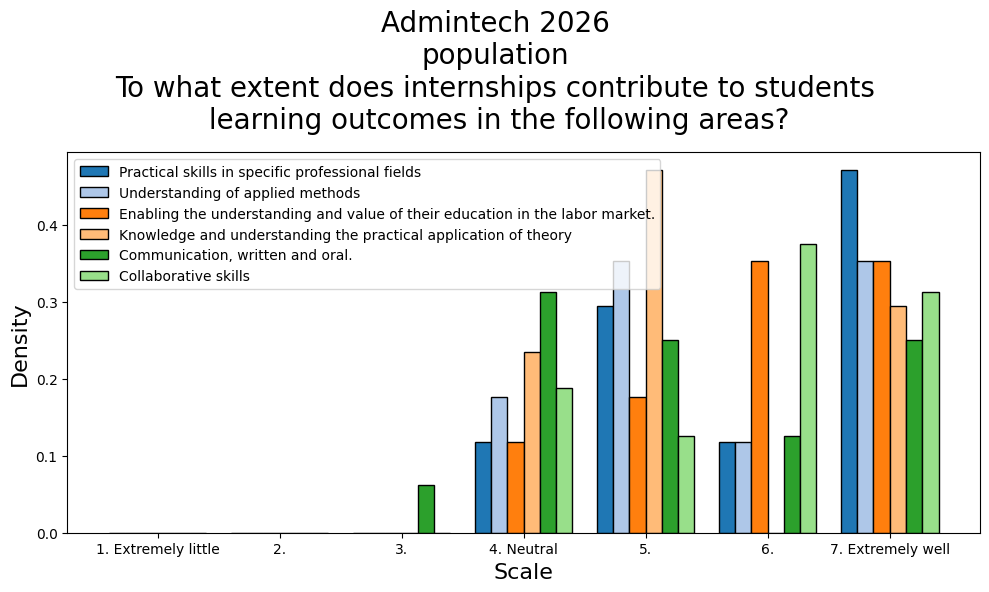

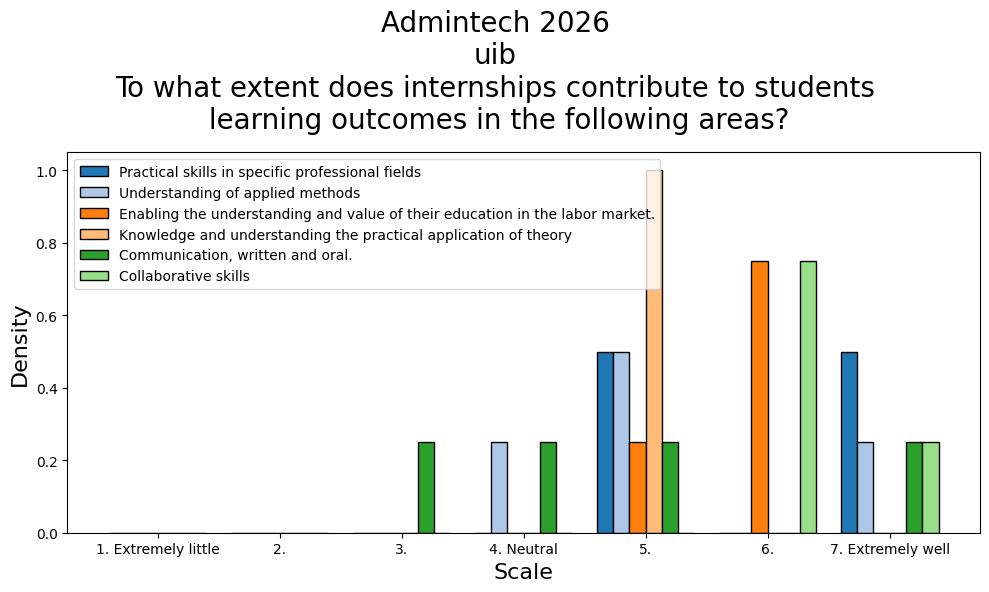

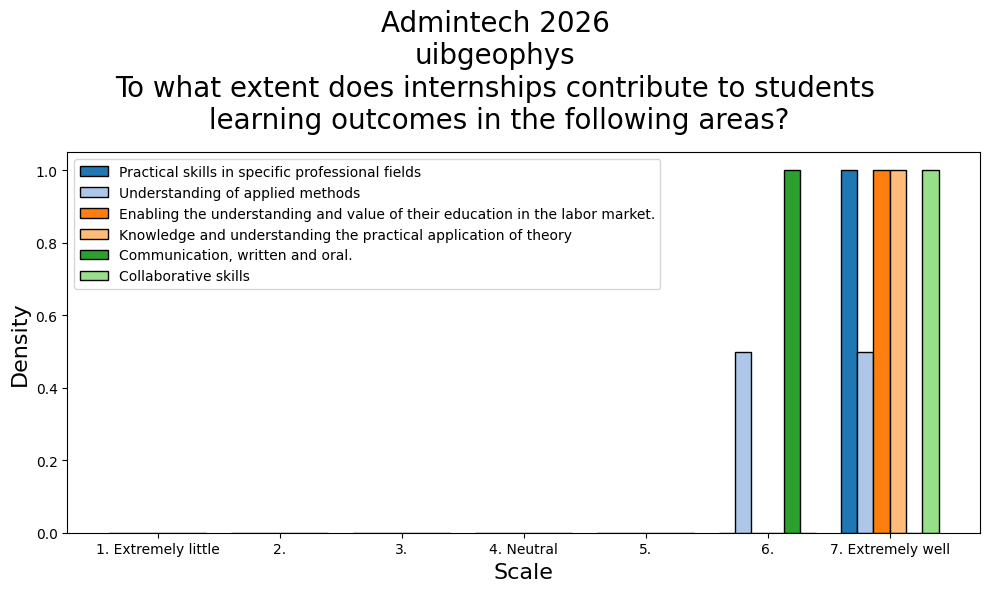

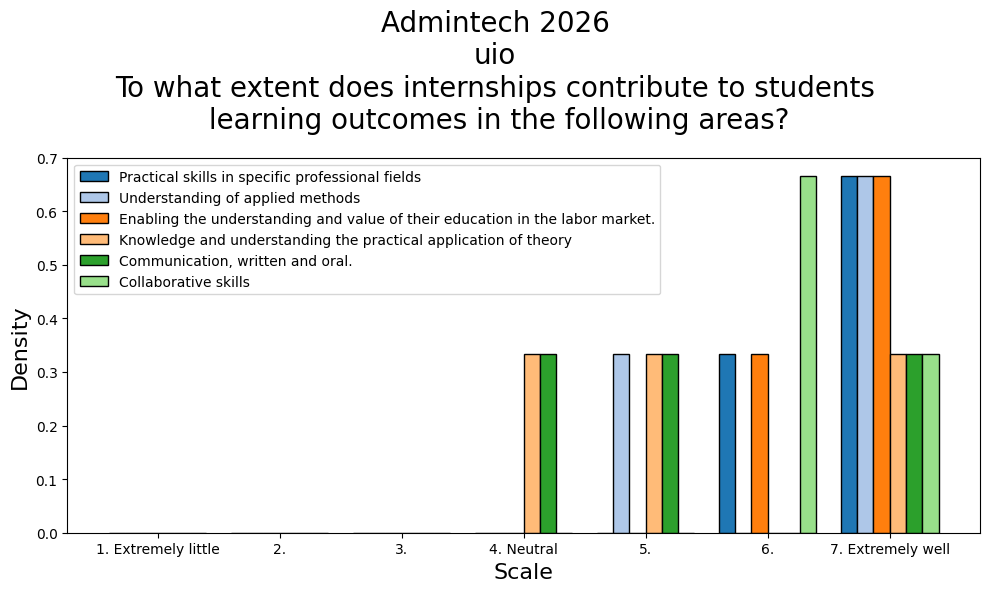

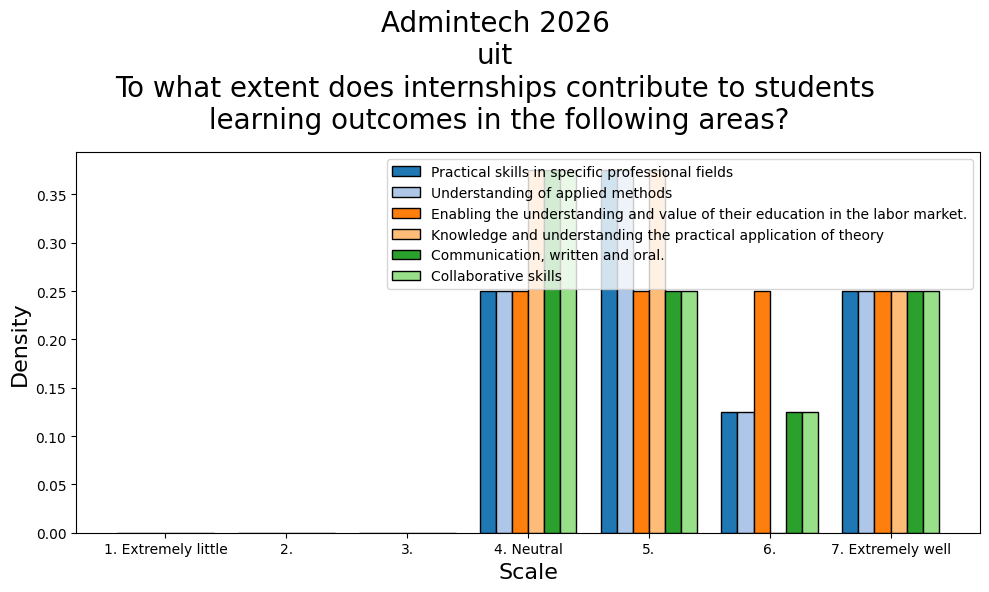

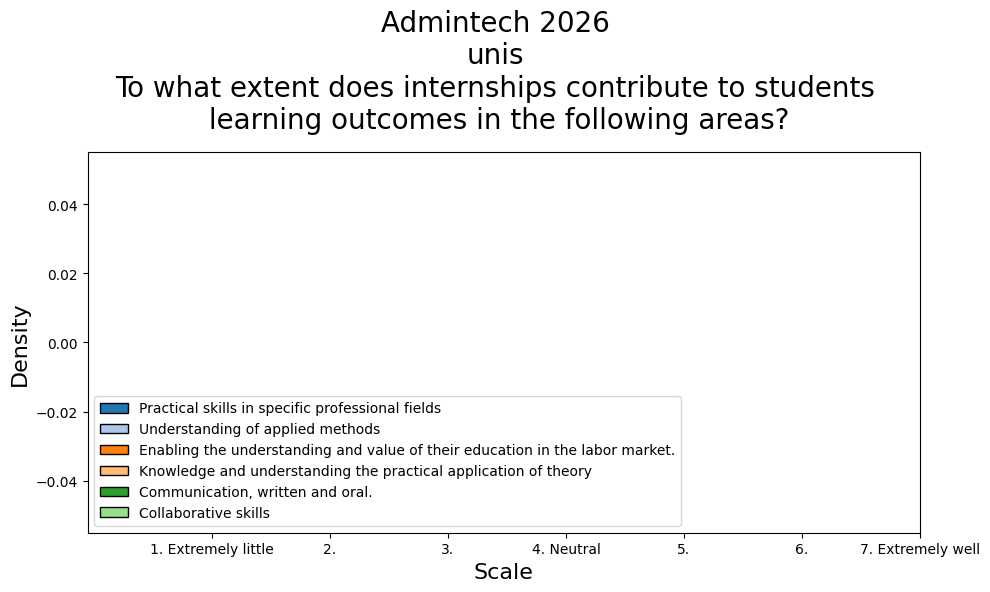

In [ ]:
from dataframe_gymnastics import load_loose_admintech_data_2026, map_institution

def plot_2026_admintech_questions(survey, group):
    std_title = f"Admintech 2026\n{group}\n"

    questions_to_plot = [
        "iEarth influenced your daily work?",
        "iEarth impacted your professional development?",
        "iEarth influenced department policies or procedures around teaching?"
    ]
    title = std_title + "To what extent has..."
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The geoscience department at UiT",
        "The geoscience department at UNIS",
        "The geoscience department at UiO",
        "The geoscience department at UiB",
        "The geophysical department at UiB",
        "Other departments (not geoscience) at a university",
        "Other geoscience departments at Norwegian universities",
        "Other geoscience departments at non-Norwegian universities",
        "Research institutions"
    ]
    title = std_title + "To what extent do you collaborate with persons at the following\ninstitutions in regard to university teaching/development and organization"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Fieldwork skills",
        "Laboratory skills",
        "Modelling/computing skills",
        "AI-competence ",
        "Quantitative competence (ability to interpret data /numeracy)",
        "Theoretical understanding",
        "Collaborating in teams",
        "Communicating scientific/technical content"
    ]
    title = std_title + "To what extent do you believe the following skills\nwill be important for geoscientists in the future?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Send information and communicate with students",
        "Redistributing classrooms, moving lessons, and similar tasks",
        "Scheduling (timeplanlegging)",
        "Organizing/editing course description",
        "Obtain administrative assistance from other institutions at the university",
        "Practical organization of field course / laboratory work",
        "Answering questions from the students"
    ]
    title = std_title + "How often do you assist academic staff in the following areas?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        " - "
    ]
    title = std_title + "To what extend do you experience that academic staff actively use the skills\n you have in planning and organizing teaching?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "The teachers’ have excellent academic competences",
        "The teachers’ have excellent pedagogical competences",
        "The collegial collaboration in regard to research is excellent",
        "The collegial collaboration in regard to teaching is excellent",
        "The collegial collaboration between academic staff and technical/administration staff is excellent",
        "The general quality of the study programme is excellent"
    ]
    title = std_title + "To what extent do you agree or disagree\n with the following statements about your department ?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "To what extent do you think the education at your institution prepare students for their future work in geoscience?", 
        "To what extent do you think there is coherence (connectedness) between the courses in the study programme?"
    ]
    title = std_title + "The study programme"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Fieldwork skills.1",
        "Laboratory skills.1",
        "Modelling/computing skills.1",
        "AI-competence .1",
        "Quantitative competence (ability to interpret data /numeracy).1",
        "Theoretical understanding.1",
        "Collaborating in teams.1",
        "Communicating scientific/technical content.1"
    ]
    title = std_title + "To what extent do the students acquire these skills\n through the geoscience studyprogramme at your institution?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Most students feel comfortable as students at the department",
        "The students are generally satisfied with their studies",
        "The students are good at helping each other",
        "There is fierce competition among the students",
        "The students have good possibilities for social contact with their fellow students",
        "The students are highly motivated to study"
    ]
    title = std_title + "It is my impression that..."
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Internships make students better prepared for the labour market",
        "Internships give students valuable experiences they cannot get at the university",
        "Internships in the study programme comes at the expense of other important learning goals at the university",
        "Internships make geoscience students more motivated"
    ]
    title = std_title + "How much do you agree with the statements below with respect to\nthe learning outcomes students acquire in internships?"
    make_shared_histogram(questions_to_plot, survey, title, hide=1)

    questions_to_plot = [
        "Practical skills in specific professional fields",
        "Understanding of applied methods",
        "Enabling the understanding and value of their education in the labor market.",
        "Knowledge and understanding the practical application of theory",
        "Communication, written and oral.",
        "Collaborative skills"
    ]
    title = std_title + "To what extent does internships contribute to students\n learning outcomes in the following areas?"
    make_shared_histogram(questions_to_plot, survey, title, hide=0)

    return

def initialize_survey_2026_admintech(group):

    survey_2026_admintech = Survey()
    survey_2026_admintech.year = 2026
    survey_2026_admintech.path = ".."

    # initialize with the population
    # survey_2026_educators.data = dataframe_dict_educators_2026["population"]
    dataframe = load_loose_admintech_data_2026()
    survey_2026_admintech.data = dataframe
    survey_2026_admintech.get_questions()

    # get all the axes to set later
    survey_2026_admintech.axes = []
    for question in survey_2026_admintech.questions:
        survey_2026_admintech.axes.append(question.axis)

    # return early
    if group == "population":
        return survey_2026_admintech


    # pick out the group using the institution map
    survey_2026_admintech.data = dataframe[dataframe["institution"] == map_institution[group]]
    survey_2026_admintech.get_questions()

    # set the axes for the group to be the same as the population axes
    for i, question in enumerate(survey_2026_admintech.questions):
        question.axis = survey_2026_admintech.axes[i]

    return survey_2026_admintech

# df_2026_admintech = initialize_survey_2026_admintech("population")
# plot_2026_admintech_questions(df_2026_admintech, "population")
# for group in ["population", "uib", "uibgeophys", "uio", "uit", "unis"]:
#     df_2026_admintech = initialize_survey_2026_admintech(group)
#     plot_2026_admintech_questions(df_2026_admintech, group)
